# Design and Analysis: Instrumental Variables (IV)

### Instrumental Variables

- IV can be generated *ex ante*:
    - Randomized promotion (or encouragement design)
    - "Randomized offering" of a program

- Here:
    - General Principles behind IV's
    - *Ex ante* focus on randomized promotion
    - IV, non-compliance and randomized offering

### An example to start off with...

- Say we wish to evaluate a volunatary job training program
    - Any unemployed person is eligible (**Universal eligibility**)
    - Some people choose to register (**Participants**)
    - Other people choose not to register (**Non-participants**)

- Some simple (but not-so-good) ways to evaluate the program:
    - Compare **before and after** situation in the **participants** group
    - Compare situation of **participants and non-participants** after the intervention
    - Compare situation of **participants and non-participants before and after** (DID)

### Voluntary job training program

Say we decide to compare outcomes for those who participate to the outcomes of those who do not partipate:

A simple way to do this: 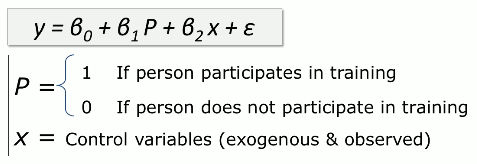

Why is this not working? 2 problems:
- Variables that we omit (for various reasons) but that are important 
- Decision to participant in training is endogenous.

### Problem #1: Omitted Variables

Even if we try to control for "everything", we'll miss:
1. Characteristics that we didn't know they mattered, and
2. Characteristics that are too complicated to measure (not observables or not observed):
    - Talent, motivation
    - Level of information and access to services
    - Opportunity cost of participation

Full model would be: 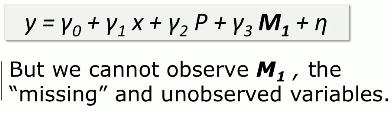

### Omitted variable bias

True model is: $ y = \gamma_0 + \gamma_1x + \gamma_2P + \gamma_3M_1 + \eta $

But we estimate: $ y = \beta_0 + \beta_1x + \beta_2P + \epsilon $

If there is a correlation between $M_1$ and *P*, then the OLS estimator of $\beta_2$ will not be a consistent estimator of $\gamma_2$, the true impact of *P*.

Why?
When $M_1$ is missing from the regression, the coefficient of *P* will "pick up" some of the effect of $M_1$

### Problem #2: Endogenous Decision to Participate 

True model is: $ y = \gamma_0 + \gamma_1X + \gamma_2P + \eta $
- with $ P = \pi_0 + \pi_1x + \pi_2M_2 + \zeta $
- $M_2 $ =Vector of unobserved / missing characteristics (i.e., we don't fully know why people decide to participate)

Since we don't observe $M_2$, we can only estimate a simplified model:

$ y = \beta_0 + \beta_1x + \beta_2P + \epsilon $ 

Is $\beta_{2, OLS} $ an unbiaed estimator of $\gamma_2$?

We estimate: $ y = \beta_0 + \beta_1x + \beta_2P + \epsilon $

But true model is: $ y = \gamma_0 + \gamma_1x + \gamma_2P + \eta$

- with $ P = \pi_0 + \pi_1x + \pi_2M_2 + \xi $ 

Is $ \beta_{2, OLS} $ an unbiased estimator of $ \gamma_2$?

$ Corr(\epsilon, P) = corr(\epsilon, \pi_0 + \pi_1x + \pi_2M_2 + \xi) $
- = $ \pi_1 corr(\epsilon, x) + \pi_2 corr(\epsilon, M_2) $
- = $ \pi_2 corr(\epsilon, M_2) $

If there is a correlation between the missing variables that determine participation (e.g. Talent) and outcomes are not explained by observed characteristics, then the OLS estimator will be biased.

### What can we do to solve this problem?

- We estimate: $ y = \beta_0 + \beta_1x + \beta_2P + \epsilon $

So the problem is the correlation between *P* and $ \epsilon $

How about we replace *P* with "something else", call it *Z*:
- *Z* needs to be correlated with *P*
- But is not correlated with $ \epsilon $

An **instrument** is a variable that determines the endogenous regressor, but only affects the dependent variable through its effect on the independent variable.

### Example 1: job training program

*P* = participation
$ \epsilon $ = the part outcomes that is not explained by program partipation or by observed characteristics

I'm looking for a variable *Z* that is:
1. Correlated with participation P
2. but doesn't directly affect people's outcomes *Y, other than through its effect on participation.*

So this variable must be coming from outside.

### Generating an outside variable for the job training program

Say that a social worker visits unemployed person to encourage them to participate.
- She only visits 50% of persons on her roster, and 
- She randomly chooses whom she will visit

If she is effective, many people she visits will enroll.
- There will be a correlation between receiving a visit and enrolling.

But visit does not have direct effect on outcomes (e.g. income) apart from its effect through enrollment in the training program.

**Randomized "encouragement"** or **"promotion" visits** are an Instrumental Variables.

### Characteristics of an instrumental variable

Define a new variable *Z*

*Z* = 
- 1   If person was randomly chosen to receive the encouragement visit from the social worker  
- 0   If person was randomly chosen to receive the encouragement visit from the social worker

$ Corr (Z, P) > 0: $ **inclusion restriction**
- People who receive the encouragement visits are more likely to participate than those who don't.

$ Corr (Z,\epsilon) = 0: $ **exclusion restriction**
- No correlation between receiving a visit and benefit to the program apart from the effect of the visit on participation.

*Z* is called an **instrumental variable** (or an **instrument**)

### Nuts and Bolts: Two-stage least squares (2SLS)

Remember the original model with endogenous P:

$ y = \beta_0 + \beta_1x + \beta_2P + \epsilon $

### Step 1:
Regress the endogenous variable *P* on the instrumental variable(s) *Z* and other exogenous variables

$ P = \delta_0 + \delta_1x + \delta_2Z + \tau $ 

- Calculate the predicted value of *P* for each observation: $ \hat{P} $
- Since *Z* and *x* are not correlated with $ \epsilon $, neither will be $ \hat{P} $

$ \hat{P} = \hat{\delta}_0 + \hat{\delta}_1x + \hat{\delta}_2Z $

### Step 2: Regress *y* on the predicted variable $ \hat{P} $ and the other exogenous variables

$ y = \beta_0 + \beta_1x + \beta_2 \hat{P} + \epsilon $

- Note: The standard errors of the second stage OLS need to be corrected because $ \hat{P} $ is not a fixed regressor.
- In Practice: Use *Python* **IV2SLS** command, which does the two steps at once and reports correct standard errors.
- Intuition: By using *Z* for *P*, we cleaned *P* of its correlayion with $ \eta $
- It can be shown that (under certain condition) $B_{2, IV} $ yeilds a consistent estimator of $ \gamma_2 $ (large sample theory) 

### Where do we find instrumental variables?

Searching for an IV *ex post* ... Hard and risky!

Generating an IV with the experiment design *ex ante*
- If everyone is eligible to participate in treatment
- But some have more information than others (Who has more inforamtion will be more likely to participate)
- Provision of "additional information" on a random basis

### Link back to the estimation formula

Stage 1
- Regress the participation on training on a dummy for whether person received additional visit (linear model)
- Compute predicted value of participation 